# Making the results file

From the MCMC chains, put together the results fits file for use in Notebook 3 (plots and analysis)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import astropy.io.fits as fits
import os
from astropy.table import Table, Column

from tqdm import tqdm

from mw_density import (
    sample_selection,
    density_profiles,
    mcmc_functions,
)

from mw_density.selection_function import SelectionFunction
from mw_density.isochrones import Isochrones
from mw_density.spectra import MaStarSSPs

sample_selection.set_env_variables()

In [ ]:
# Define save name to save results to
# save_filename = "results/density_params_TESTING.fits"
save_filename = "mw_density_params.fits"

In [3]:
age_bins, mh_bins = sample_selection.setup_maap_bins()
apogee_sample = fits.open("../data/apogee_sample.fits")[1].data

logg_min_lim = np.min(apogee_sample["LOGG"])
logg_max_lim = np.max(apogee_sample["LOGG"])

metals = apogee_sample["M_H"]
alphas = apogee_sample["ALPHA_M"]
ages = apogee_sample["AGE"]
data_rs = apogee_sample["GALACTIC_R"]
data_zs = apogee_sample["GALACTIC_Z"]

In [ ]:
unique_id = "4-22-25"
# unique_id = "2_14_25"

In [ ]:
# MAAP Definitions
pop_alpha = []
pop_metal = []
pop_age = []
min_age = []
max_age = []
min_mh = []
max_mh = []
N_obs = []
i_m_list = []
i_a_list = []
bin_id = []

# Parameters
params_med = []
params_max = []
lnprobs = []

parameter_arrays = [[] for i in range(5)]
parameter_errs = [[] for i in range(5)]


# Loop through all bins to add results to array
with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha, alpha_iter in enumerate(["LOW", "HIGH"]):
        bin_counter = 0
        for i_m, mh in enumerate(mh_bins["center"]):
            for i_a, age in enumerate(age_bins["center"]):
                pbar.update(1)
                # SET POPULATION PARAMETERS
                alpha_num = i_alpha
                i_m_list.append(i_m)
                i_a_list.append(i_a)
                bin_id.append(bin_counter)
                pop_alpha.append(alpha_iter)
                pop_metal.append(np.round(mh_bins["center"][i_m], 2))
                pop_age.append(np.round(age_bins["center"][i_a], 2))
                min_age.append(np.round(age_bins["min"][i_a], 2))
                max_age.append(np.round(age_bins["max"][i_a], 2))
                min_mh.append(np.round(mh_bins["min"][i_m], 2))
                max_mh.append(np.round(mh_bins["max"][i_m], 2))
                m = (
                    (apogee_sample["METAL_BIN_I"] == i_m)
                    & (apogee_sample["AGE_BIN_I"] == i_a)
                    & (apogee_sample["ALPHA_BIN"] == alpha_iter)
                )
                N_obs.append(len(m[m]))

                # READ PARAMETERS FROM MCMC CHAIN
                if alpha_iter == "LOW":
                    chainfile = "mcmc_chains/"
                    chainfile += f"bin{bin_counter}_{unique_id}.npz"
                else:
                    chainfile = "mcmc_chains/"
                    chainfile += f"bin{bin_counter}_{unique_id}_high.npz"

                if not os.path.exists(chainfile):
                    if len(m[m]) >= 100:
                        # there should be a chain, but there's not??
                        print(len(m[m]))
                        print(chainfile)
                    lnprobs.append(np.nan)
                    params_med.append(np.nan * np.ones(5))
                    params_max.append(np.nan * np.ones(5))
                    for i, p_list in enumerate(parameter_arrays):
                        parameter_arrays[i].append(np.nan)
                        parameter_errs[i].append([np.nan, np.nan])

                else:
                    chain = np.load(chainfile)["chain"]
                    lnprob = np.load(chainfile)["flatlnprobability"]
                    # Make sure values are finite
                    chain = chain[np.isfinite(lnprob)]
                    lnprob = lnprob[np.isfinite(lnprob)]
                    nwalkers, burn_in, niter = mcmc_functions.mcmc_config()
                    # Define last 10% of steps for best results
                    last_n = int(nwalkers * niter * 0.1)
                    max_ps = chain[-last_n:][np.argmax(lnprob[-last_n:])]
                    med_ps = np.nanmedian(chain[-last_n:], axis=0)
                    probval = lnprob[-last_n:][np.argmax(lnprob[-last_n:])]
                    # max_ps = chain[np.argmax(lnprob)]
                    # med_ps = np.nanmedian(chain, axis=0)
                    # probval = lnprob[np.argmax(lnprob)]
                    lnprobs.append(probval)
                    # one sigma asymmetrical errors
                    lower_sigma = np.percentile(
                        # chain[-last_n:], 50 - 34, axis=0
                        chain,
                        50 - 34,
                        axis=0,
                    )
                    upper_sigma = np.percentile(
                        # chain[-last_n:], 50 + 34, axis=0
                        chain,
                        50 + 34,
                        axis=0,
                    )

                    params_med.append(med_ps)
                    params_max.append(max_ps)

                    # FINAL PARAMETER VALUES
                    for i, p_list in enumerate(parameter_arrays):
                        if i in [0, 1]:  # hr_in or hr_out - report as kpc
                            p = 1.0 / med_ps[i]
                            errs = [
                                1.0 / (med_ps[i] - lower_sigma[i]),
                                1.0 / (upper_sigma[i] - med_ps[i]),
                            ]
                        else:
                            p = med_ps[i]
                            errs = [p - lower_sigma[i], upper_sigma[i] - p]
                            # print(errs)
                        parameter_arrays[i].append(p)
                        parameter_errs[i].append(errs)

                bin_counter += 1


p1, p2, p3, p4, p5 = parameter_arrays
p1e, p2e, p3e, p4e, p5e = parameter_errs

In [ ]:
# Quick QA check
tm = np.copy(p1).reshape((2, len(mh_bins["center"]), len(age_bins["center"])))
plt.subplot(121)
plt.imshow(tm[0], origin="lower", vmin=-5, vmax=5)
plt.subplot(122)
plt.imshow(tm[1], origin="lower", vmin=-5, vmax=5)
plt.colorbar()
plt.show()

plt.subplot(121)
tm = np.copy(p2).reshape((2, len(mh_bins["center"]), len(age_bins["center"])))
plt.imshow(tm[0], origin="lower", vmin=0, vmax=5)
plt.subplot(122)
plt.imshow(tm[1], origin="lower", vmin=0, vmax=5)
plt.colorbar()
plt.show()

tm = np.copy(p4).reshape((2, len(mh_bins["center"]), len(age_bins["center"])))
plt.subplot(121)
plt.imshow(tm[0], origin="lower", vmin=0, vmax=20)
plt.subplot(122)
plt.imshow(tm[1], origin="lower", vmin=6, vmax=12)
plt.colorbar()
plt.show()


# Add columms for parameters

In [ ]:
# Save out file
fitstable = Table()
for col in [
    Column(
        pop_alpha, name="ALPHA_M", description="alpha-group of the population"
    ),
    Column(
        pop_metal,
        name="M_H",
        description="Central metallicity of the population",
    ),
    Column(
        pop_age,
        name="AGE",
        description="Central age of the population",
        unit="Gyr",
    ),
    Column(
        np.array([round(x, 2) for x in np.log10(np.array(pop_age) * 1.0e9)]),
        name="LOG_AGE",
        description="Central age of the population (log10)",
        unit="log10(yr)",
    ),
    Column(
        N_obs,
        name="N_STARS_OBS",
        description="Number of stars in the population bin",
    ),
    Column(
        min_age,
        name="MIN_AGE",
        description="Minimum age of the population bin",
        unit="Gyr",
    ),
    Column(
        max_age,
        name="MAX_AGE",
        description="Maximum age of the population bin",
        unit="Gyr",
    ),
    Column(
        min_mh,
        name="MIN_M_H",
        description="Minimum [M/H] of the population bin",
    ),
    Column(
        max_mh,
        name="MAX_M_H",
        description="Maximum [M/H] of the population bin",
    ),
    Column(i_m_list, name="INDX_MH", description="Index of the [M/H] bin"),
    Column(i_a_list, name="INDX_AGE", description="Index the age bin"),
    Column(
        bin_id, name="INDX_BIN", description="Index of the age and [M/H] bin"
    ),
    Column(
        p1,
        name="HR_IN",
        description="Inner disk Scale Length",
        unit="kpc",
    ),
    Column(
        p1e,
        name="HR_IN_ERR",
        description="Uncertaintiy in inner disk Scale Length",
        unit="kpc",
    ),
    Column(
        p2, name="HR_OUT", description="Outer disk Scale Length", unit="kpc"
    ),
    Column(
        p2e,
        name="HR_OUT_ERR",
        description="Uncertaintiy in outer disk Scale Length",
        unit="kpc",
    ),
    Column(p4, name="R_BREAK", description="Break Radius", unit="kpc"),
    Column(
        p4e,
        name="R_BREAK_ERR",
        description="Uncertaintiy in break radius",
        unit="kpc",
    ),
    Column(
        p3,
        name="H_Z",
        description="Scale height measured at R_Sun",
        unit="kpc",
    ),
    Column(
        p3e,
        name="H_Z_ERR",
        description="Uncertainty in scale height",
        unit="kpc",
    ),
    Column(p5, name="A_FLARE", description="Linear flaring term"),
    Column(
        p5e,
        name="A_FLARE_ERR",
        description="Uncertainty in linear flaring term",
    ),
    Column(
        params_med,
        name="PARAMS_MED",
        description="Best fit parameter array (median of MCMC chain)",
    ),
    Column(
        params_max,
        name="PARAMS_MAX",
        description="Best fit parameter array (maximum likelihood of chain)",
    ),
]:
    fitstable.add_column(col)

fitstable.write(save_filename, format="fits", overwrite=True)
sample_selection.write_file_header(save_filename)

In [ ]:
JHK_isochrones = Isochrones()
mass_ratio = JHK_isochrones.calc_mass_ratio()

selfunc = SelectionFunction()


In [ ]:
# Calculate nu_0 from the observation counts

# Attempt to calculate nu_0 from the star counts after the fits
# idk save some arrays and make some plots
nu_0 = []
nu_0_errs = []
mass_ratio_for_bin = []
eff_volumes = []
NU0_ARRAY = np.zeros((2, len(mh_bins["center"]), len(age_bins["center"])))

# High alpha bins
N_bins = len(mh_bins["center"]) * len(age_bins["center"])

fit_params = fits.open(save_filename)[1].data

densmodel = density_profiles.combined_exp_profile_nonsmoothed_linear

with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha, alpha_iter in enumerate(["LOW", "HIGH"]):
        bin_counter = 0
        for i_m, mh in enumerate(mh_bins["center"]):
            for i_a, age in enumerate(age_bins["center"]):
                pbar.update(1)

                table_indx = np.where(
                    (fit_params["INDX_MH"] == i_m)
                    & (fit_params["INDX_AGE"] == i_a)
                    & (fit_params["ALPHA_M"] == alpha_iter)
                )[0][0]

                assert fit_params["INDX_BIN"][table_indx] == bin_counter

                best_fit_params = fit_params["PARAMS_MED"][table_indx]
                # print(f"Parameters: {best_fit_params}")

                data_binmask = mcmc_functions.get_sample_data_mask(
                    apogee_sample, i_m, i_a, alpha_iter
                )

                observed_counts = len(data_binmask[data_binmask])
                oc2 = fit_params[table_indx]["N_STARS_OBS"]
                assert observed_counts == oc2
                mass_ratio_for_bin.append(mass_ratio[i_m, i_a])

                if observed_counts < 100:
                    nu_0.append(np.nan)
                    nu_0_errs.append([np.nan, np.nan])
                else:
                    bin_effsel = selfunc.effsel[bin_counter]
                    effsel_mask = (bin_effsel.flatten() != 0) & (
                        np.isfinite(bin_effsel.flatten())
                    )
                    bin_effsel_rs = selfunc.coordinates["r"][effsel_mask]
                    bin_effsel_zs = selfunc.coordinates["z"][effsel_mask]
                    bin_effsel = bin_effsel.flatten()[effsel_mask]
                    eff_volume = selfunc.calc_eff_survey_volume(bin_counter)
                    # print(f"Eff Volume: {eff_volume[0]}")
                    effsel_dict = {
                        "bin_effsel": bin_effsel,
                        "bin_effsel_rs": bin_effsel_rs,
                        "bin_effsel_zs": bin_effsel_zs,
                        "eff_volume": np.array(eff_volume[1])[effsel_mask],
                    }
                    eff_volumes.append(effsel_dict["eff_volume"])

                    dens_effsel = densmodel(
                        best_fit_params.astype("float64"),
                        effsel_dict["bin_effsel_rs"],
                        effsel_dict["bin_effsel_zs"],
                    )

                    if np.nansum(dens_effsel) == 0:
                        print(params_max[table_indx])

                    dens_effsel_counts = np.nansum(
                        (dens_effsel * effsel_dict["eff_volume"])
                    )
                    # calculate nu0
                    norm_nu0 = np.log10(1.0 / dens_effsel_counts)
                    nu0 = np.log10(np.e**norm_nu0)
                    nu_0.append(nu0)
                    NU0_ARRAY[i_alpha, i_m, i_a] = nu0

                    # Calculate uncertainties!!!
                    lowerr_params = []
                    uperr_params = []
                    for p in ["HR_IN", "HR_OUT", "H_Z", "R_BREAK", "A_FLARE"]:
                        lw = (
                            fit_params[p][table_indx]
                            - fit_params[f"{p}_ERR"][table_indx][0]
                        )
                        uw = (
                            fit_params[p][table_indx]
                            + fit_params[f"{p}_ERR"][table_indx][1]
                        )
                        if (p == "HR_IN") | (p == "HR_OUT"):
                            lowerr_params.append(1.0 / lw)
                            uperr_params.append(1.0 / uw)
                        else:
                            lowerr_params.append(lw)
                            uperr_params.append(uw)

                    lw_dens_effsel = densmodel(
                        np.array(lowerr_params).astype("float64"),
                        effsel_dict["bin_effsel_rs"],
                        effsel_dict["bin_effsel_zs"],
                    )
                    uw_dens_effsel = densmodel(
                        np.array(uperr_params).astype("float64"),
                        effsel_dict["bin_effsel_rs"],
                        effsel_dict["bin_effsel_zs"],
                    )

                    lw_dens_effsel_counts = np.nansum(
                        (lw_dens_effsel * effsel_dict["eff_volume"])
                    )
                    uw_dens_effsel_counts = np.nansum(
                        (uw_dens_effsel * effsel_dict["eff_volume"])
                    )

                    lw_nu0 = np.log10(
                        np.e ** (np.log10(1.0 / lw_dens_effsel_counts))
                    )
                    uw_nu0 = np.log10(
                        np.e ** (np.log10(1.0 / uw_dens_effsel_counts))
                    )

                    nu_0_errs.append(
                        [np.abs(nu0 - lw_nu0), np.abs(uw_nu0 - nu0)]
                    )
                    # print(nu0)
                    # print(nu_0_errs[-1])

                bin_counter += 1

In [ ]:
print(nu_0[100])
print(nu_0_errs[100])

In [ ]:
tm = np.copy(nu_0).reshape(
    (2, len(mh_bins["center"]), len(age_bins["center"]))
)
plt.subplot(121)
plt.imshow(tm[0], origin="lower")
plt.subplot(122)
plt.imshow(tm[1], origin="lower")
plt.show()


In [ ]:
# "TOTAL SMD (integrate over z)"
total_smd = (
    np.ones((2, len(mh_bins["center"]), len(age_bins["center"]))) * np.nan
)

z_samp = np.linspace(1e-5, 10, 100)


alps = ["LOW", "HIGH"]

SMD_ARRAY = []
SMD_ARRAY_ERRS = []

with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha, alpha_iter in enumerate(["LOW", "HIGH"]):
        bin_counter = 0
        for i_m, mh in enumerate(mh_bins["center"]):
            for i_a, age in enumerate(age_bins["center"]):
                pbar.update(1)
                table_indx = np.where(
                    (fit_params["INDX_MH"] == i_m)
                    & (fit_params["INDX_AGE"] == i_a)
                    & (fit_params["ALPHA_M"] == alpha_iter)
                )[0][0]
                best_fit_params = fit_params["PARAMS_MAX"][table_indx]
                n_stars = fit_params["N_STARS_OBS"][table_indx]
                nu0 = nu_0[table_indx]
                lw_nu0 = nu0 - nu_0_errs[table_indx][0]
                uw_nu0 = nu0 + nu_0_errs[table_indx][1]
                # print(f"Parameters: {best_fit_params}")
                if np.isfinite(nu0):
                    all_smds = []
                    for nu in [lw_nu0, nu0, uw_nu0]:
                        # print([lw_nu0, nu0, uw_nu0])
                        bfp = np.append(np.copy(best_fit_params), nu)
                        bfp = best_fit_params.astype("float64")
                        tot_mass_r = []
                        m = densmodel(
                            bfp, 8.122 * np.ones(len(z_samp)), z_samp
                        )
                        smd = np.trapezoid(m, x=z_samp)
                        # Convert from number dens to mass dens
                        smd = smd * mass_ratio[i_m][i_a] * n_stars * nu / nu0
                        smd = smd / 1e6  # convert from kpc-2 to pc-2
                        # print(smd)
                        all_smds.append(smd)
                    # print(all_smds)
                    # Save to arrays
                    smd = all_smds[1]
                    lower_err = all_smds[1] - all_smds[0]
                    upper_err = all_smds[2] - all_smds[1]
                    total_smd[i_alpha, i_m, i_a] = smd
                    SMD_ARRAY.append(smd)
                    SMD_ARRAY_ERRS.append([lower_err, upper_err])
                    # print([lower_err,upper_err])

                else:
                    SMD_ARRAY.append(np.nan)
                    SMD_ARRAY_ERRS.append([np.nan, np.nan])


print(f"TOTAL LOW: {np.nansum(SMD_ARRAY[:180])}")
print(f"TOTAL HIGH: {np.nansum(SMD_ARRAY[180:])}")
print(f"TOTAL ALL: {np.nansum(SMD_ARRAY)}")
# PRINT ERRORS
err1 = np.sqrt(np.nansum(np.array(SMD_ARRAY_ERRS[:180]) ** 2, axis=0))
err2 = np.sqrt(np.nansum(np.array(SMD_ARRAY_ERRS[180:]) ** 2, axis=0))
err3 = np.sqrt(np.nansum(np.array(SMD_ARRAY_ERRS) ** 2, axis=0))
print(f"LOW ERRS: {err1}")
print(f"HIGH ERRS: {err2}")
print(f"TOTAL ERRS: {err3}")


In [ ]:
# "TOTAL mass (not just p0)"
total_mass = (
    np.ones((2, len(mh_bins["center"]), len(age_bins["center"]))) * np.nan
)
r_samp = np.linspace(1e-5, 30, 1000)
# z_samp = np.linspace(1e-5, 10, 1000)
z_samp = np.linspace(-10, 10, 1000)

TOTMASS_ARRAY = []
TOTMASS_ERRS = []
with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha in [0, 1]:
        for i_m in range(len(mh_bins["center"])):
            for i_a in range(len(age_bins["center"])):
                pbar.update(1)
                mh = mh_bins["center"][i_m]
                age = age_bins["center"][i_a]
                table_indx = np.where(
                    (fit_params["M_H"] == round(mh, 2))
                    & (fit_params["AGE"] == round(age, 2))
                    & (fit_params["ALPHA_M"] == alps[i_alpha])
                )[0][0]
                best_fit_params = fit_params["PARAMS_MED"][table_indx]
                n_stars = fit_params["N_STARS_OBS"][table_indx]
                nu0 = np.log(10 ** (nu_0[table_indx]))
                if np.isfinite(nu0):
                    # best_fit_params = np.append(best_fit_params, nu0)
                    best_fit_params = best_fit_params.astype("float64")
                    tot_mass_r = []
                    for r in r_samp:
                        m = densmodel(
                            best_fit_params, r * np.ones(len(z_samp)), z_samp
                        )
                        if np.isfinite(np.nansum(m)):
                            tot_mass_r.append(np.trapezoid(m, x=z_samp))

                    totmass = nu0 * np.trapezoid(tot_mass_r, x=r_samp)
                    # Convert from number dens to mass dens
                    totmass = totmass * mass_ratio[i_m][i_a] * n_stars
                    # Save to arrays
                    total_mass[i_alpha, i_m, i_a] = totmass
                    TOTMASS_ARRAY.append(np.log10(totmass))

                    # Calculate errors
                    lw_nu0 = nu0 - nu_0_errs[table_indx][0]
                    lw_totmass = lw_nu0 * np.trapezoid(tot_mass_r, x=r_samp)
                    lw_totmass = lw_totmass * mass_ratio[i_m][i_a] * n_stars
                    uw_nu0 = nu0 + nu_0_errs[table_indx][1]
                    uw_totmass = uw_nu0 * np.trapezoid(tot_mass_r, x=r_samp)
                    uw_totmass = uw_totmass * mass_ratio[i_m][i_a] * n_stars
                    TOTMASS_ERRS.append(
                        [totmass - lw_totmass, uw_totmass - totmass]
                    )
                    # print(totmass)
                    # print([totmass - lw_totmass, uw_totmass - totmass])

                else:
                    TOTMASS_ARRAY.append(np.nan)
                    TOTMASS_ERRS.append([np.nan, np.nan])

low_sum = np.nansum(10 ** np.array(TOTMASS_ARRAY)[:180])
ls1, ls2 = (
    np.nansum(np.array(TOTMASS_ERRS)[:180].T[0]),
    np.nansum(np.array(TOTMASS_ERRS)[:180].T[1]),
)
high_sum = np.nansum(10 ** np.array(TOTMASS_ARRAY)[180:])
hs1, hs2 = (
    np.nansum(np.array(TOTMASS_ERRS)[180:].T[0]),
    np.nansum(np.array(TOTMASS_ERRS)[180:].T[1]),
)
total_sum = low_sum + high_sum
ts1, ts2 = (
    np.nansum(np.array(TOTMASS_ERRS).T[0]),
    np.nansum(np.array(TOTMASS_ERRS).T[1]),
)

print(f"TOTAL LOW: {low_sum:e} -{ls1:e} +{ls2:e}")
print(f"TOTAL HIGH: {high_sum:e} -{hs1:e} +{hs2:e}")
print(f"TOTAL ALL:  {(low_sum + high_sum):e} -{ts1:e} +{ts2:e}")


In [ ]:
tm = np.copy(TOTMASS_ARRAY).reshape(
    (2, len(mh_bins["center"]), len(age_bins["center"]))
)
# Error arrays
le_tm = np.copy(np.array(TOTMASS_ERRS).T[0]).reshape(
    (2, len(mh_bins["center"]), len(age_bins["center"]))
)
ue_tm = np.copy(np.array(TOTMASS_ERRS).T[1]).reshape(
    (2, len(mh_bins["center"]), len(age_bins["center"]))
)

plt.subplot(121)
plt.imshow(tm[0], origin="lower")
plt.colorbar()
plt.subplot(122)
plt.imshow(tm[1], origin="lower")
plt.show()

low_sfh = np.nansum(10 ** tm[0], axis=0)
low_sfh_lowerr = np.nansum(le_tm[0], axis=0)
low_sfh_uperr = np.nansum(ue_tm[0], axis=0)

high_sfh = np.nansum(10 ** tm[1], axis=0)
high_sfh_lowerr = np.nansum(le_tm[1], axis=0)
high_sfh_uperr = np.nansum(ue_tm[1], axis=0)

tot_sfh = low_sfh + high_sfh

# mw_mass = 4.58e10
mw_mass = np.nansum(tot_sfh)

low_sfh = low_sfh / np.sum(tot_sfh) * mw_mass / 1e10
high_sfh = high_sfh / np.sum(tot_sfh) * mw_mass / 1e10
tot_sfh = tot_sfh / np.sum(tot_sfh) * mw_mass / 1e10
low_sfh_lowerr = low_sfh_lowerr / 1e10
low_sfh_uperr = low_sfh_uperr / 1e10
high_sfh_lowerr = high_sfh_lowerr / 1e10
high_sfh_uperr = high_sfh_uperr / 1e10

fig, ax = plt.subplots(figsize=(16, 8))
ax.plot(
    age_bins["center"],
    tot_sfh,
    c="k",
    label=r"Total",
    drawstyle="steps-mid",
    lw=5,
)

# ax.fill_between(
#     age_bins["center"],
#     low_sfh-low_sfh_lowerr,
#     low_sfh+low_sfh_uperr,
#     facecolor="tab:blue",
#     step="mid",
#     alpha=0.3
# )

ax.plot(
    age_bins["center"],
    low_sfh,
    c="tab:blue",
    label=r"Low-$\alpha$",
    drawstyle="steps-mid",
    lw=5,
)

# ax.fill_between(
#     age_bins["center"],
#     high_sfh-high_sfh_lowerr,
#     high_sfh+high_sfh_uperr,
#     facecolor="tab:red",
#     step="mid",
#     alpha=0.3)

ax.plot(
    age_bins["center"],
    high_sfh,
    c="tab:red",
    label=r"High-$\alpha$",
    drawstyle="steps-mid",
    lw=5,
)
ax.legend(loc="upper right")

for x in age_bins["min"]:
    ax.axvline(x, c="lightgray", alpha=0.5)

ax.grid(axis="y")

ax.set_xscale("log")
ax.get_xaxis().set_major_formatter(mpl.ticker.ScalarFormatter())
ax.set_xlim(13.7, age_bins["min"][0])
# ax.set_xticks(age_bins_min)
# ax.set_xticklabels([round(a, 1) for a in age_bins_min])

ax.set_xticks([1, 2, 3, 5, 10, 13.7])
ax.set_xticklabels([1, 2, 3, 5, 10, 13.7])

# plt.title('Mass Assembly/SFH?')
plt.xlabel("Stellar Age (Gyr)")
plt.ylabel(r"Stellar Mass ($\times 10^{10} M_{\odot}$)")


# z_age=np.array([13.7, 11.270, 8.628,5.903,3.316,2.171,1.186])
# z_age=13.7-np.array([13.7, 11.270, 8.628,5.903,3.316,2.171,1.186])
z_age = 13.7 - np.array(
    [13.7 - age_bins["min"][0], 11.270, 8.628, 5.903, 3.316, 2.171, 1.186]
)
z = [0, 0.2, 0.5, 1, 2, 3, 5]

cax2 = ax.twiny()
cax2.set_xscale("log")
cax2.set_xlabel(r"redshift (z)")
cax2.set_xticks(z_age)
cax2.set_xticklabels(z)
cax2.set_xlim(13.7, age_bins["min"][0])

# plt.savefig(figure_directory + "sfh.png", bbox_inches="tight")
plt.show()


In [ ]:
TOTMASS_ERRS[100]

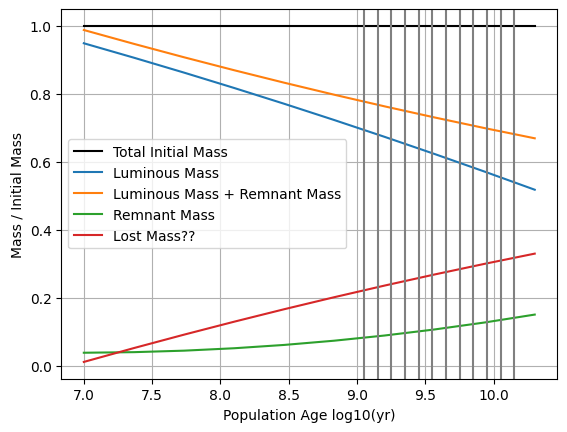

In [4]:
# Convert from initial mass to surviving mass from Zasowski et al.
sample_ages = np.linspace(7, 10.3, 10)

lum_mass_frac_left = 1.502 - 0.044 * sample_ages - 0.005 * sample_ages**2.0
# lum_mass = lum_mass_frac_left*data['MASS_SMOOTH']

aged_mass_frac_left = 2.024 - 0.183 * sample_ages + 0.005 * sample_ages**2.0
# aged_mass = aged_mass_frac_left*data['MASS_SMOOTH']

plt.plot(
    sample_ages,
    np.ones(len(sample_ages)),
    c="k",
    label="Total Initial Mass",
)
plt.plot(sample_ages, lum_mass_frac_left, label="Luminous Mass")

plt.plot(
    sample_ages,
    aged_mass_frac_left,
    label="Luminous Mass + Remnant Mass",
)
plt.plot(
    sample_ages,
    aged_mass_frac_left - lum_mass_frac_left,
    label="Remnant Mass",
)
plt.plot(
    sample_ages,
    1.0 - aged_mass_frac_left,
    label="Lost Mass??",
)

for a in age_bins["center"]:
    plt.axvline(np.log10(a * 1e9), c="gray")

plt.xlabel("Population Age log10(yr)")
plt.ylabel("Mass / Initial Mass")
plt.grid()

plt.legend()
plt.show()

In [ ]:
AGED_MASS_FRACTION = []

for age in pop_age:
    frac = np.interp(np.log10(age * 1e9), sample_ages, aged_mass_frac_left)
    AGED_MASS_FRACTION.append(frac)

In [ ]:
tab = Table.read(save_filename)

for column in [
    Column(
        np.array(nu_0),
        name="NU_0",
        description="Number Density at R_Sun",
        unit="kpc^-3",
    ),
    Column(
        np.array(nu_0_errs),
        name="NU_0_ERRS",
        description="Uncertainty in number density",
        unit="kpc^-3",
    ),
    Column(
        np.array(SMD_ARRAY),
        name="SMD_0",
        description="Surface Mass Density at R_Sun",
        unit="solMass pc^-2",
    ),
    Column(
        np.array(SMD_ARRAY_ERRS),
        name="SMD_0_ERRS",
        description="Uncertainties in Surface Mass Density",
        unit="solMass pc^-2",
    ),
    Column(
        np.array(TOTMASS_ARRAY),
        name="LOG_STELLAR_MASS",
        description="Total Initial Mass of the Stellar Population",
        unit="log10(solMass)",
    ),
    Column(
        np.log10(np.array(TOTMASS_ERRS)),
        name="LOG_STELLAR_MASS_ERRS",
        description="Uncertainty in log total initial stellar mass",
        unit="log10(solMass)",
    ),
    Column(
        np.array(AGED_MASS_FRACTION),
        name="AGED_MASS_FRACTION",
        description="Fraction of Stellar Mass (luminous mass + remnant mass) remaining after population ages",
    ),
    Column(
        np.log10(
            (10 ** np.array(TOTMASS_ARRAY)) * np.array(AGED_MASS_FRACTION)
        ),
        name="AGED_LOG_STELLAR_MASS",
        description="Aged Stellar Mass of the Stellar Population (luminous mass + remnant mass)",
        unit="log10(solMass)",
    ),
]:
    try:
        tab.add_column(column)
    except ValueError:
        # column already exists - update values instead
        tab.replace_column(column.name, column)

tab.write(save_filename, format="fits", overwrite=True)
sample_selection.write_file_header(save_filename)

# Add columns with R and Z profiles??

In [ ]:
r_samp = np.linspace(0.01, 30, 100)
z_samp = np.linspace(0.01, 5, 100)


ALL_R_PROFS = []
ALL_Z_PROFS = []
ALL_HZ_PROFS = []


with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha in [0, 1]:
        for i_m in range(len(mh_bins["center"])):
            for i_a in range(len(age_bins["center"])):
                pbar.update(1)
                mh = mh_bins["center"][i_m]
                age = age_bins["center"][i_a]
                params_i = np.where(
                    (fit_params["M_H"] == round(mh, 2))
                    & (fit_params["AGE"] == round(age, 2))
                    & (fit_params["ALPHA_M"] == alps[i_alpha])
                )[0][0]
                best_fit_params = [
                    1.0 / fit_params["HR_IN"][params_i],
                    1.0 / fit_params["HR_OUT"][params_i],
                    fit_params["H_Z"][params_i],
                    fit_params["R_BREAK"][params_i],
                    fit_params["A_FLARE"][params_i],
                    NU0_ARRAY[i_alpha][i_m][i_a],
                ]

                if not np.isfinite(best_fit_params[0]):
                    ALL_R_PROFS.append(np.nan * np.ones(len(r_samp)))
                    ALL_Z_PROFS.append(np.nan * np.ones(len(z_samp)))
                    ALL_HZ_PROFS.append(np.nan * np.ones(len(r_samp)))
                else:
                    r_prof = density_profiles.radial_broken_exp(
                        1.0 / fit_params["HR_IN"][params_i],
                        1.0 / fit_params["HR_OUT"][params_i],
                        fit_params["R_BREAK"][params_i],
                        r_samp,
                    )
                    z_prof = density_profiles.z_profile_flaring(
                        fit_params["H_Z"][params_i],
                        fit_params["A_FLARE"][params_i],
                        np.ones(len(z_samp)) * 8.122,
                        z_samp,
                    )
                    hz_prof = (
                        fit_params["A_FLARE"][params_i] * (r_samp - 8.122)
                    ) + fit_params["H_Z"][params_i]

                    ALL_R_PROFS.append(r_prof)
                    ALL_Z_PROFS.append(z_prof)
                    ALL_HZ_PROFS.append(hz_prof)


In [ ]:
tab = Table.read(save_filename)

for column in [
    Column(
        np.array([r_samp for i in range(len(ALL_R_PROFS))]),
        name="R_GRID",
        description="Array of radius values RADIAL_DENS_PROFILE column",
        unit="kpc",
    ),
    Column(
        np.array([z_samp for i in range(len(ALL_R_PROFS))]),
        name="Z_GRID",
        description="Array of Z values for VERTICAL_DENS_PROFILE column",
        unit="kpc",
    ),
    Column(
        np.array(ALL_R_PROFS),
        name="RADIAL_DENS_PROFILE",
        description="Radial density profile calculated for R_GRID at Z = 0 ",
        unit="kpc^-3",
    ),
    Column(
        np.array(ALL_Z_PROFS),
        name="VERTICAL_DENS_PROFILE",
        description="Vertical density calculated for Z_GRID at R_Sun",
        unit="kpc^-3",
    ),
    Column(
        np.array(ALL_HZ_PROFS),
        name="HZ_R_PROFILE",
        description="Profile of scale height H_Z as a function of R",
        unit="kpc",
    ),
]:
    try:
        tab.add_column(column)
    except ValueError:
        # column already exists - update values instead
        tab.replace_column(column.name, column)

tab.write(save_filename, format="fits", overwrite=True)
sample_selection.write_file_header(save_filename)

# Add column with MaStar SSP Spectra

In [ ]:
MaStarSSPs = MaStarSSPs()
ssp_wls = []
ssp_list = []

with tqdm(total=2 * len(mh_bins["center"]) * len(age_bins["center"])) as pbar:
    for i_alpha, alpha_iter in enumerate(["LOW", "HIGH"]):
        bin_counter = 0
        for i_m in range(len(mh_bins["center"])):
            for i_a in range(len(age_bins["center"])):
                pbar.update(1)
                bin_counter += 1
                ssp_list.append(
                    MaStarSSPs.get_ssp(
                        age_bins["center"][i_a], mh_bins["center"][i_m]
                    )
                )
                ssp_wls.append(MaStarSSPs.wls)

In [ ]:
tab = Table.read(save_filename)

for column in [
    Column(
        ssp_wls,
        name="SSP_WLS",
        description="Wavelength array for SSP Spectrum",
    ),
    Column(
        ssp_list,
        name="SSP_FLUX",
        description="Flux array for SSP Spectrum",
    ),
]:
    try:
        tab.add_column(column)
    except ValueError:
        # column already exists - update values instead
        tab.replace_column(column.name, column)

tab.write(save_filename, format="fits", overwrite=True)
sample_selection.write_file_header(save_filename)